# Chapter 8: The Relational Algebra and Relational Calculus


## Teaching Summary

How can a query be explained as operations on small tables? This notebook covers
the course's selected relational algebra from Sections 8.1-8.3 and simple
compositions from 8.5 of Elmasri and Navathe, *Fundamentals of Database Systems*,
seventh edition. Division, relational calculus, aggregate algebra, recursion, and
formal query optimization are not assigned here.

Read Chapter 5 first: relations, tuples, attributes, keys, and references. You should
be able to predict selected rows, projected attributes, set-operation results,
Cartesian products, and joins, then combine them into a query. The supplied SQL
checks your predictions; SQL writing is taught in Chapter 6.

All data and diagrams are synthetic teaching examples. Inputs contain no NULLs.
Classical set operations and SQL NULL behavior are not interchangeable; Chapter 7
handles SQL's additional cases. Output sorting is for readability, not a claim
that a relation has an inherent tuple order.


## 1. Start with Small Relations

The student relation describes students; enrollment describes registrations.
S101's DB1 registrations in two terms are distinct tuples, not duplicates.

| student_id | student_name | dept_code |
|---|---|---|
| S101 | An Chen | IM |
| S102 | Bea Lin | FIN |
| S103 | Kai Wu | IM |

| student_id | course_id | term |
|---|---|---|
| S101 | DB1 | F26 |
| S101 | DB1 | S27 |
| S102 | DB1 | F26 |

| course_id | credits |
|---|---|
| DB1 | 3 |
| AI1 | 2 |

A relational algebra operation returns another relation. That result can become
the input to another operation. It does not change a stored relation by itself.
R and S below stand for input relations; |R| means the number of tuples in R.

**Predict:** How many student and enrollment tuples exist? How many distinct student
IDs occur in enrollment? Is S103 missing from student or only from enrollment?


### Three registrations do not mean three registered students

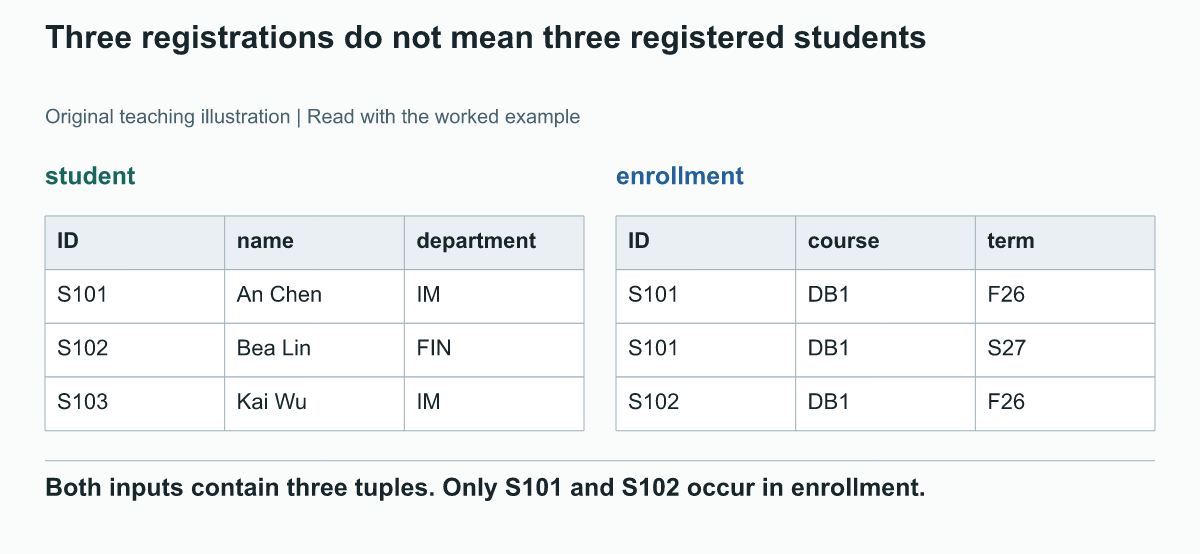

Both inputs contain three tuples. Only S101 and S102 occur in enrollment.


### Read the Diagram

There are three rows in each of student and enrollment, but enrollment contains
only two distinct student IDs. S103 is a stored student without a registration.

Run the setup once. Each later query uses a fresh database with these same inputs
and closes it afterward. These helper functions display SQL results; they are not
a new relational algebra language students must learn.


In [1]:
import sqlite3

def algebra_database():
    db = sqlite3.connect(":memory:", isolation_level=None)
    db.execute("PRAGMA foreign_keys = ON")
    db.executescript("""
        CREATE TABLE student (
            student_id TEXT NOT NULL PRIMARY KEY,
            student_name TEXT NOT NULL,
            dept_code TEXT NOT NULL
        );
        CREATE TABLE course (
            course_id TEXT NOT NULL PRIMARY KEY,
            credits INTEGER NOT NULL
        );
        CREATE TABLE enrollment (
            student_id TEXT NOT NULL REFERENCES student(student_id),
            course_id TEXT NOT NULL REFERENCES course(course_id),
            term TEXT NOT NULL,
            PRIMARY KEY(student_id, course_id, term)
        );
        CREATE TABLE db_club (student_id TEXT NOT NULL PRIMARY KEY);
        CREATE TABLE ai_club (student_id TEXT NOT NULL PRIMARY KEY);
        INSERT INTO student VALUES
            ('S101','An Chen','IM'), ('S102','Bea Lin','FIN'), ('S103','Kai Wu','IM');
        INSERT INTO course VALUES ('DB1',3), ('AI1',2);
        INSERT INTO enrollment VALUES
            ('S101','DB1','F26'), ('S101','DB1','S27'), ('S102','DB1','F26');
        INSERT INTO db_club VALUES ('S101'), ('S102');
        INSERT INTO ai_club VALUES ('S102'), ('S103');
    """)
    return db

def result(sql):
    db = algebra_database()
    try:
        cursor = db.execute(sql)
        rows = cursor.fetchall()
        print(" | ".join(c[0] for c in cursor.description))
        for row in rows:
            print(" | ".join(str(value) for value in row))
        if not rows:
            print("(no rows)")
        return rows
    finally:
        db.close()

_ = result("SELECT * FROM student ORDER BY student_id")


student_id | student_name | dept_code
S101 | An Chen | IM
S102 | Bea Lin | FIN
S103 | Kai Wu | IM


The setup preserved all three students. Each query result will have its own schema;
do not count printed column headings as tuples.

**Practice:** Write S101's two complete enrollment tuples. Explain why projecting
only student_id would hide their difference. Check the term values.


## 2. SELECT Keeps Rows That Satisfy a Condition

The symbol σ (sigma) denotes selection. In σ<sub>dept_code='IM'</sub>(student),
the subscript is the condition and student is the input relation.
The result keeps every attribute but only tuples satisfying that condition.

Selection cannot increase the tuple count: 0 ≤ |σ<sub>condition</sub>(R)| ≤ |R|.
Its degree remains the same. Conditions can use AND, OR, and NOT with comparisons
appropriate to the domain. Here the input values are non-missing.

**Predict:** Which IDs survive the IM condition? How many attributes remain?
What would a condition dept_code='MED' return?


### Filter by department; retain all attributes

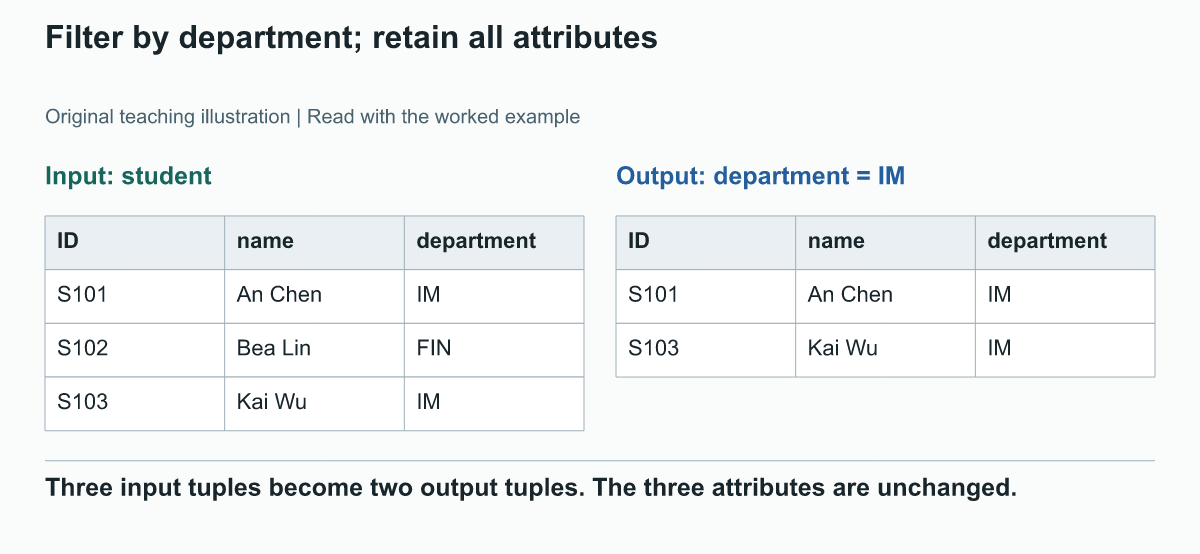

Three input tuples become two output tuples. The three attributes are unchanged.


### Read the Diagram

S101 and S103 satisfy the IM condition; both keep their name and department.
MED matches no row. An empty result still has the student relation's attributes.


In [2]:
_ = result("SELECT * FROM student WHERE dept_code='IM' ORDER BY student_id")
_ = result("SELECT * FROM student WHERE dept_code='MED' ORDER BY student_id")


student_id | student_name | dept_code
S101 | An Chen | IM
S103 | Kai Wu | IM
student_id | student_name | dept_code
(no rows)


The first result has two tuples and three attributes; the second has zero tuples
and the same attributes. Neither query deletes a stored student.
Relational SELECT corresponds to SQL's WHERE filtering, not to SQL's column list.

**Practice:** Predict the IDs for dept_code='IM' AND student_id='S103', then for the
same two conditions joined with OR. Check each input row against both conditions.


## 3. PROJECT Keeps Attributes and Removes Duplicate Tuples

The symbol π (pi) denotes projection. In π<sub>dept_code</sub>(student), the
subscript lists the retained attributes. The projected relation has one attribute.
Repeated projected tuples are removed because the result is a set.

**Predict:** How many department tuples remain? Would retaining student_id as well
preserve three tuples?


### Remove duplicate complete projected tuples

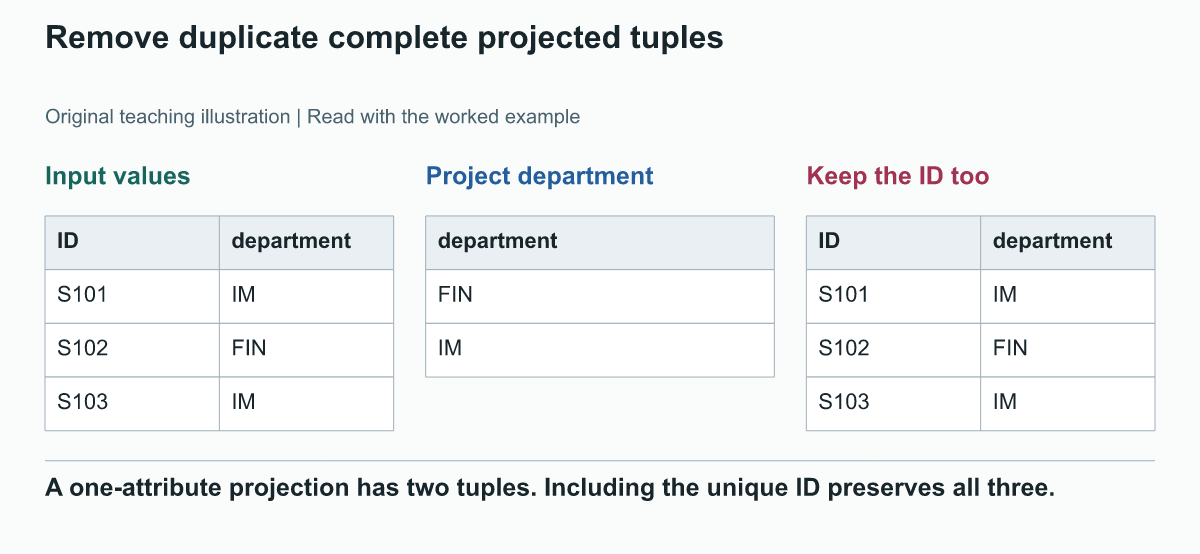

A one-attribute projection has two tuples. Including the unique ID preserves all three.


### Read the Diagram

The input departments are IM, FIN, IM. The projection is {IM, FIN}, not three
department tuples. Including the student key keeps the students distinguishable.


In [3]:
_ = result("SELECT DISTINCT dept_code FROM student ORDER BY dept_code")
_ = result("SELECT DISTINCT student_id, dept_code FROM student ORDER BY student_id")
_ = result("SELECT dept_code FROM student ORDER BY student_id")


dept_code
FIN
IM
student_id | dept_code
S101 | IM
S102 | FIN
S103 | IM
dept_code
IM
FIN
IM


DISTINCT gives the set projection. Without DISTINCT, the last SQL result retains
two IM rows. This SQL result is not the same relation as the one-attribute set
projection. The stored table remains unchanged.

**Practice:** Project course_id from enrollment, then project course_id and term.
Write the attributes and distinct tuples in each result. Check duplicate elimination
on the complete projected tuple, not on each value independently.


## 4. Name Intermediate Results and Preserve Needed Attributes

The symbol ρ (rho) denotes renaming; it changes a relation name, attribute names,
or both without changing tuple values. Renaming helps express compatible schemas
or distinguish roles. It does not turn a department code into a student ID.

An assignment arrow ← gives an intermediate result a name:
IM_STUDENTS ← σ<sub>dept_code='IM'</sub>(student).
Then RESULT ← π<sub>student_id,student_name</sub>(IM_STUDENTS).
Read the inner operation first when nesting these expressions.

**Predict:** What information would be lost if you projected student_name alone
before applying the department condition?


### Check a condition before removing its attribute

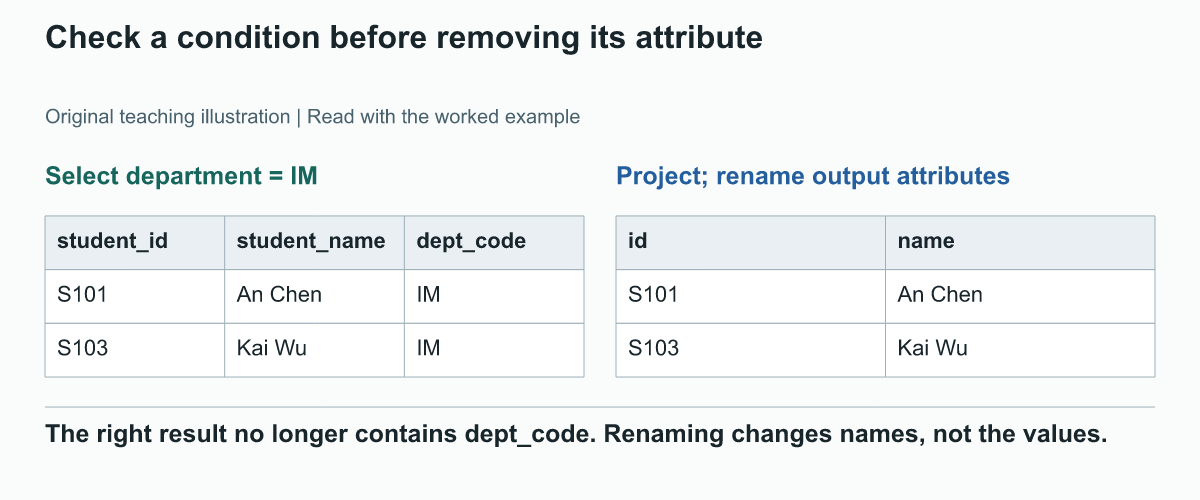

The right result no longer contains dept_code. Renaming changes names, not the values.


### Read the Diagram

Selecting first keeps the department available for checking. Projecting the name
alone removes dept_code, so that later condition cannot be evaluated on the result.
The operations cannot be reordered without checking the needed attributes.


In [4]:
_ = result("""SELECT student_id AS id, student_name AS name
              FROM student WHERE dept_code='IM' ORDER BY id""")


id | name
S101 | An Chen
S103 | Kai Wu


The output renames the two retained attributes to id and name. Values still describe
the same two students. SQL AS implements these output names; it does not rename
the stored student columns.

**Practice:** Name a result containing FIN students, then project and rename its
student ID attribute. Write the result schema and tuple. Check that every condition
uses an attribute still available at that step.


## 5. UNION, INTERSECTION, and DIFFERENCE Compare Sets

These operations need **union-compatible** inputs: the same number of attributes
and matching domains in corresponding positions. Rename attributes when needed to
make the intended correspondence clear. Similar SQL storage types alone do not
establish that two columns mean the same kind of value.

Let R = db_club and S = ai_club. Each has one student_id attribute.
R contains S101 and S102; S contains S102 and S103.

| Operation | Symbol | Membership rule |
|---|---|---|
| UNION | R ∪ S | In either input or both, without duplicates |
| INTERSECTION | R ∩ S | In both inputs |
| DIFFERENCE | R − S | In R but not in S |

**Predict:** List each result and also S − R. Does S102 appear twice in the union?
Is a one-column list of course IDs a suitable replacement for S?


### Compare the same student-ID domain

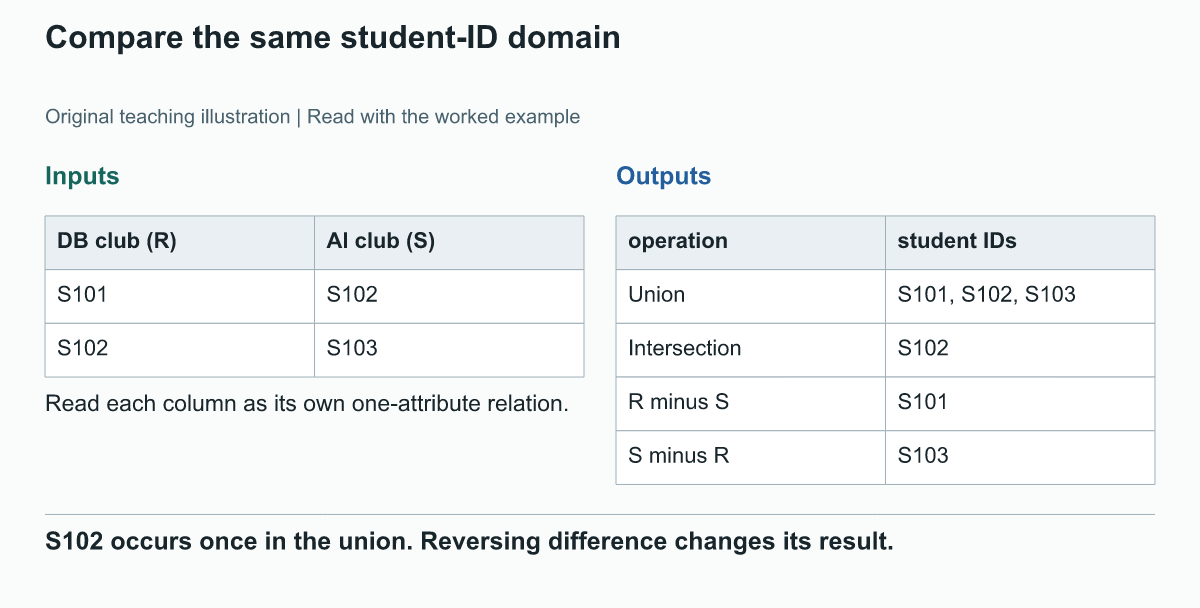

S102 occurs once in the union. Reversing difference changes its result.


### Read the Diagram

The union contains three IDs, intersection only S102, and R − S only S101.
S − R instead contains S103. Difference is directional; union and intersection
are not. A course-ID list has a different intended domain, even if stored as TEXT.


In [5]:
for label, sql in [
    ("Union", "SELECT student_id FROM db_club UNION SELECT student_id FROM ai_club ORDER BY student_id"),
    ("Intersection", "SELECT student_id FROM db_club INTERSECT SELECT student_id FROM ai_club ORDER BY student_id"),
    ("DB only", "SELECT student_id FROM db_club EXCEPT SELECT student_id FROM ai_club ORDER BY student_id"),
    ("AI only", "SELECT student_id FROM ai_club EXCEPT SELECT student_id FROM db_club ORDER BY student_id"),
]:
    print(label)
    _ = result(sql)


Union
student_id
S101
S102
S103
Intersection
student_id
S102
DB only
student_id
S101
AI only
student_id
S103


The outputs match the membership rules, including the direction of subtraction.
UNION ALL would retain both occurrences of S102 and is not set union.

**Practice:** On paper add S101 to ai_club. Recompute the intersection and DB-only
difference. Check each ID against both membership lists, including an empty result.


## 6. CARTESIAN PRODUCT Makes Every Pair

The symbol × denotes Cartesian product. For R × S, combine every tuple from R
with every tuple from S. If the inputs have m and n tuples, the result has m × n
tuples; their attribute counts add. Rename or qualify conflicting attribute names.

Our three students paired with two courses yield six possible pairs. These are not
six actual registrations: the operation did not read enrollment.

**Predict:** Does S103 appear with DB1 even though S103 has no registration?
What happens to the product if either input is empty?


### Three students times two courses gives six pairs

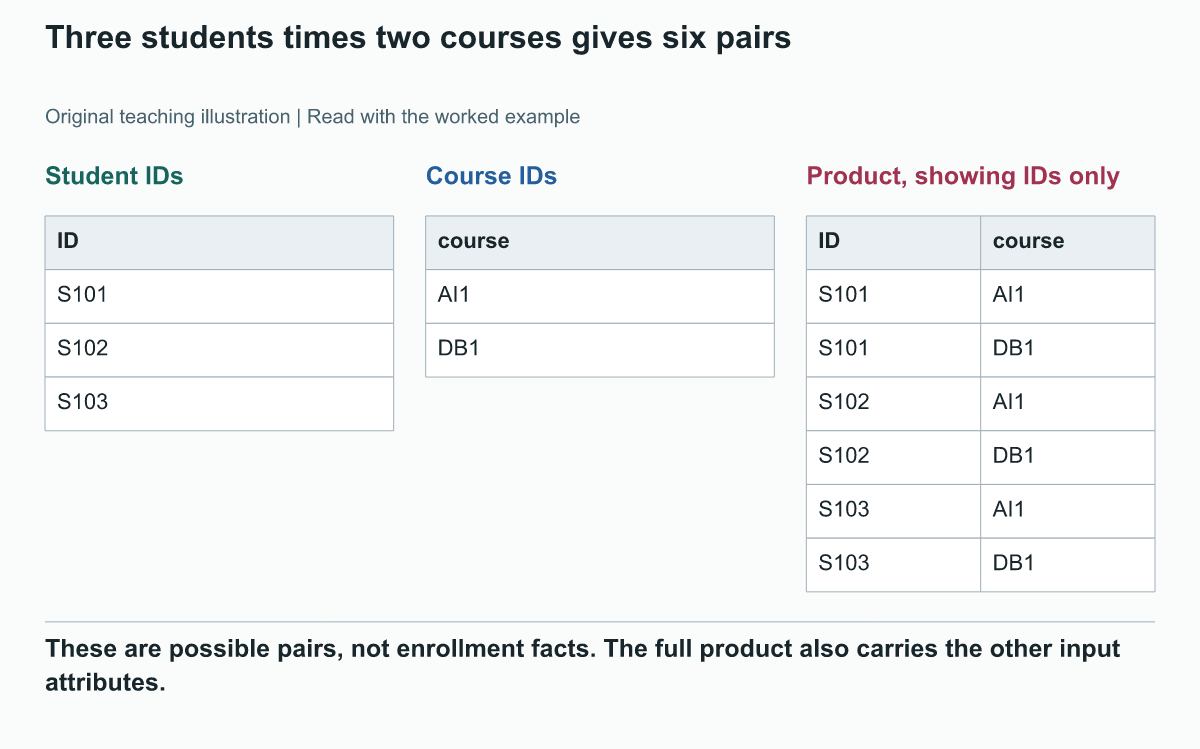

These are possible pairs, not enrollment facts. The full product also carries the other input attributes.


### Read the Diagram

Every student appears with DB1 and AI1, so S103 appears twice. An empty input gives
zero pairs. Valid syntax does not make every pairing a true enrollment.


In [6]:
_ = result("""SELECT s.student_id, c.course_id
              FROM student AS s CROSS JOIN course AS c
              ORDER BY s.student_id, c.course_id""")


student_id | course_id
S101 | AI1
S101 | DB1
S102 | AI1
S102 | DB1
S103 | AI1
S103 | DB1


Six rows match 3 × 2. These are the projected ID pairs from the product; the full
product also contains names, departments, and credits.

**Practice:** Add a third course on paper. Predict the number of pairs and list
only S103's pairs. Explain why none of them proves an enrollment took place.


## 7. JOIN Keeps Matching Pairs

The symbol ⋈ denotes a condition join. R ⋈<sub>condition</sub> S is equivalent
to σ<sub>condition</sub>(R × S): pair tuples, then keep those satisfying the condition.
A **theta join** uses a comparison condition; an **equijoin** uses equality.
The equijoin retains both compared attributes unless projected afterward.

For student and enrollment, compare their student_id attributes. The ID columns
are qualified below so their roles are distinct. All matching registrations remain.

**Predict:** How many rows match? Why does S101 appear twice, and why is S103 absent?
What would happen without the matching condition?


### One student may match several registrations

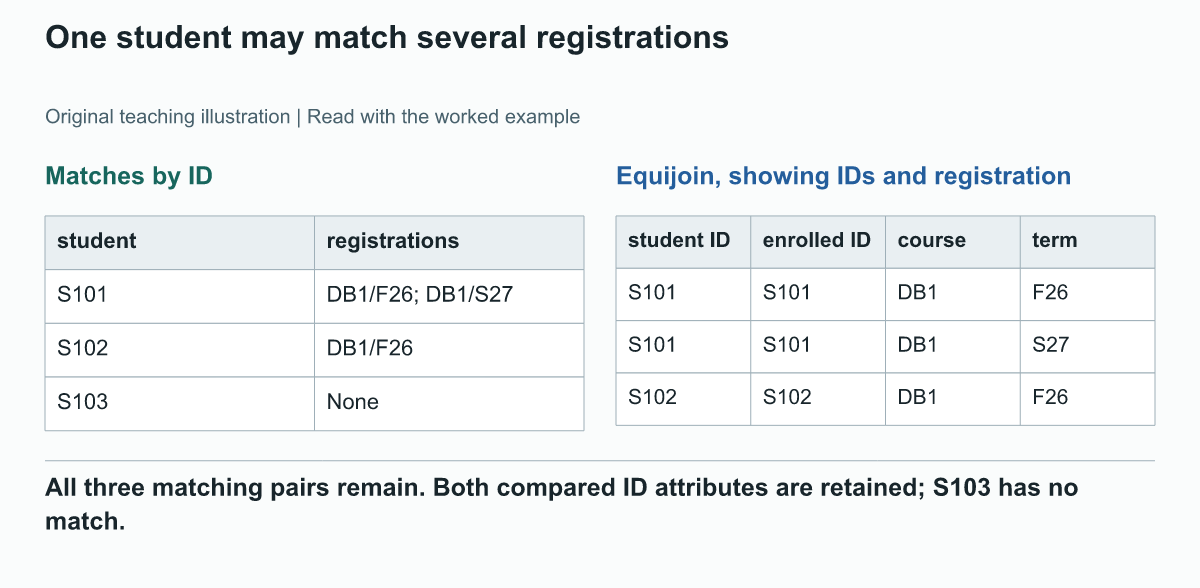

All three matching pairs remain. Both compared ID attributes are retained; S103 has no match.


### Read the Diagram

S101 matches two registrations and S102 matches one; S103 matches none.
The join has three rows, not one row per student. Without the condition there would
be 3 × 3 = 9 pairs.


In [7]:
_ = result("""SELECT s.student_id AS student_id, e.student_id AS enrolled_id,
                     e.course_id, e.term
              FROM student AS s JOIN enrollment AS e ON s.student_id=e.student_id
              ORDER BY s.student_id, e.term""")


student_id | enrolled_id | course_id | term
S101 | S101 | DB1 | F26
S101 | S101 | DB1 | S27
S102 | S102 | DB1 | F26


The two ID attributes have equal values but different roles in the equijoin.
Repeated S101 values are not duplicate full result tuples.

For a simple non-equality theta join, compare the credits of two copies of course:
one copy as c and one as d. The condition c.credits < d.credits asks which course
has fewer credits than another.

**Predict:** Which ordered course pair satisfies that inequality?


In [8]:
_ = result("""SELECT c.course_id AS lower_course, d.course_id AS higher_course
              FROM course AS c JOIN course AS d ON c.credits < d.credits
              ORDER BY lower_course, higher_course""")


lower_course | higher_course
AI1 | DB1


AI1 has 2 credits and DB1 has 3. The reverse pair and self-pairs fail the strict
inequality. A join need not be an equality or follow a declared foreign key.

**Practice:** Replace < with = on paper. List the matching ordered pairs.
Then predict the student/enrollment result restricted to F26. Check complete
tuples and do not remove S101 merely because its ID repeats in the input.


## 8. NATURAL JOIN Uses Every Shared Attribute Name

The textbook writes natural join as R * S. It matches equality on every common
attribute name and retains one copy of each shared attribute. Rename attributes
first if their names conceal different meanings.

Student and enrollment share only student_id, so their natural join uses the
intended student reference. But consider a small offering relation with
(student_id, dept_code): its dept_code means the course's department, not the
student's major. One offering row is (S101, FIN), while S101's major is IM.

**Predict:** Will a natural join keep that offering? Will joining explicitly on
student_id keep it?


### Same attribute name can hide different meanings

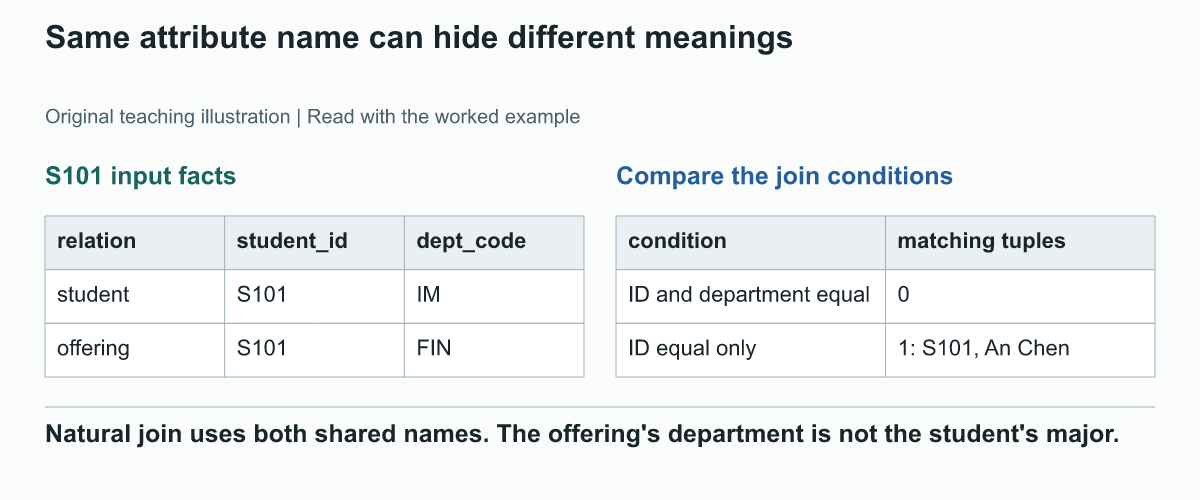

Natural join uses both shared names. The offering's department is not the student's major.


### Read the Diagram

The natural join demands both matching IDs and matching department codes, so it
drops the offering. An explicit ID join matches S101. The same column name did
not establish the same meaning.


In [9]:
_ = result("""SELECT student_id, student_name, course_id, term
              FROM student NATURAL JOIN enrollment ORDER BY student_id, term""")
_ = result("""WITH offering(student_id, dept_code) AS (VALUES ('S101','FIN'))
              SELECT s.student_id, s.student_name
              FROM student AS s NATURAL JOIN offering""")
_ = result("""WITH offering(student_id, dept_code) AS (VALUES ('S101','FIN'))
              SELECT s.student_id, s.student_name
              FROM student AS s JOIN offering AS o ON s.student_id=o.student_id""")


student_id | student_name | course_id | term
S101 | An Chen | DB1 | F26
S101 | An Chen | DB1 | S27
S102 | Bea Lin | DB1 | F26
student_id | student_name
(no rows)
student_id | student_name
S101 | An Chen


The empty middle result reflects an unintended second equality. The last result
answers the ID relationship requested. A natural join changes when additional
shared attribute names are introduced.

**Practice:** Rename offering.dept_code to offering_dept on paper. Identify the
remaining natural-join condition. Check meanings and the complete shared-name list.


## 9. Combine Operations to Answer a Question

Question: which IM students enrolled in DB1 during F26? Keep IDs with names so
students sharing a name remain distinguishable.

1. Select IM tuples from student.
2. Select DB1/F26 tuples from enrollment.
3. Join the two results on student_id.
4. Project student_id and student_name.

**Predict:** Write both selected inputs, then the matching pair and final tuple.
If step 2 omitted the term condition, would the join and final projection have
the same tuple counts?


### Find IM students registered in DB1 during F26

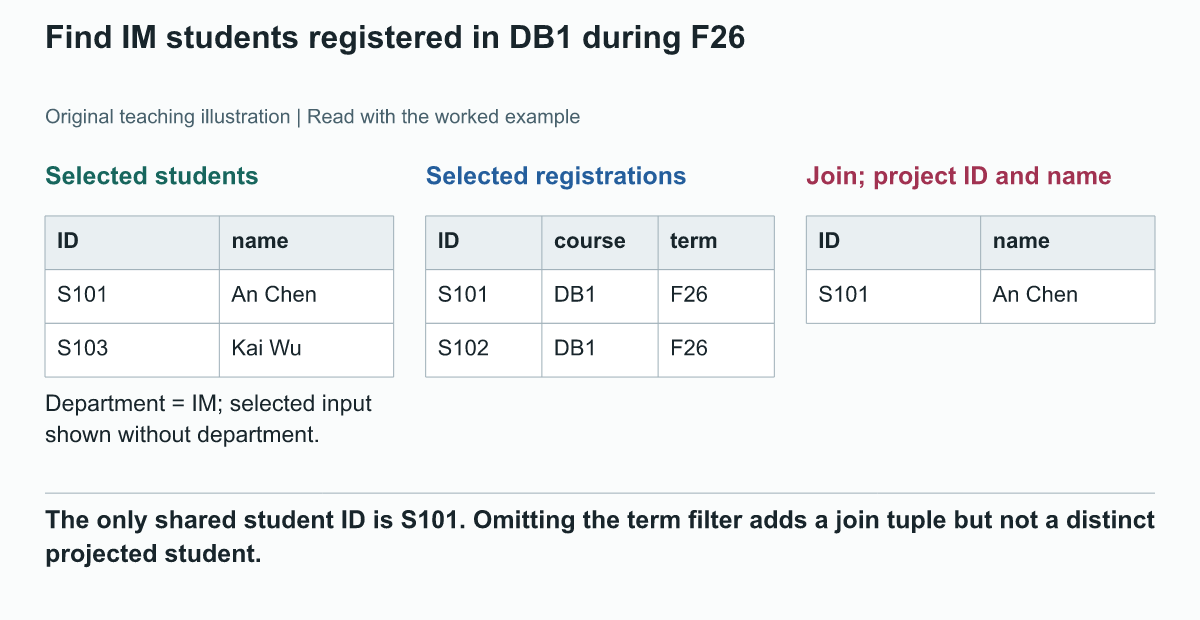

The only shared student ID is S101. Omitting the term filter adds a join tuple but not a distinct projected student.


### Read the Diagram

The selected student input contains S101 and S103; the registration input contains
S101 and S102. Their ID match is S101. The final result is (S101, An Chen).
Without the term restriction, S101 would match twice before set projection.


In [10]:
_ = result("""SELECT DISTINCT s.student_id, s.student_name
              FROM student AS s JOIN enrollment AS e ON s.student_id=e.student_id
              WHERE s.dept_code='IM' AND e.course_id='DB1' AND e.term='F26'
              ORDER BY s.student_id""")
_ = result("""SELECT student_id FROM student
              EXCEPT SELECT student_id FROM enrollment ORDER BY student_id""")


student_id | student_name
S101 | An Chen
student_id
S103


The first output answers the combined question. The second answers a different
question: all student IDs minus registered IDs, leaving S103. Keeping the domain
as student IDs makes that difference meaningful.

**Practice:** Change the first question to FIN students in DB1/F26. Draw the
intermediate relations before checking the SQL. Then find IDs in neither club:
start with all student IDs and subtract the union. Check the domain and operation
order; preserve an empty relation with its attribute name when appropriate.


## Chapter Summary

Selection filters tuples; projection chooses attributes and eliminates duplicate
tuples. Renaming preserves values while clarifying names. Compatible set operations
compare membership; product creates every pair; a condition join keeps matching
pairs. Natural join uses all common attribute names, not just the intended key.

For one query, retain the input tables, named operation or expression, predicted
result, observed output, and a correction or explanation of why the prediction was
correct. For paper work, retain intermediate relations and a rule-based check.
Submit only assigned work.

This chapter's diagrams describe logical results, not measured execution plans.
No query-optimizer implementation or speed comparison is required. Continue to
Chapter 6: Basic SQL to write the queries and data definitions yourself.
